<a href="https://www.kaggle.com/code/ashikuzzamanshishir/test-module?scriptVersionId=282600038" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Bone Fracture Detection – Deep Learning Pipeline

This notebook presents a **complete deep learning pipeline** for detecting bone fractures from X-ray images.  
It covers CNN backbones, attention modules, transformer architectures, cross-validation, and Grad-CAM visualization — all fully automated and GPU-ready.


##  1. Environment Setup
Import dependencies, define dataset paths, and configure GPU/CPU usage.  
Prepare all required folders and initialize the workspace.


In [2]:


import os, sys, shutil, random, glob, time, json, gc, math
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from statsmodels.stats.contingency_tables import mcnemar

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger


try:
    import torch, timm
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    TORCH_OK = True
except Exception:
    TORCH_OK = False

print("TensorFlow:", tf.__version__)
print("PyTorch ok:", TORCH_OK)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

TensorFlow: 2.18.0
PyTorch ok: False


## 2. Data Preparation
Load the bone fracture dataset, verify class distribution, and split into **train**, **validation**, and **test** sets.  
Applies consistent directory-based structure for compatibility with Keras and PyTorch.

## 3.  Dataset Structure & Image Counting

 This helps verify that the dataset is loaded correctly before any preprocessing or model training begins.


In [3]:

DATA_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_work"
SPLIT_ROOT = os.path.join(WORK_DIR, "splits")
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")
AUG_TRAIN_DIR = os.path.join(SPLIT_ROOT, "train_aug2")
MIXT_DIR  = os.path.join(SPLIT_ROOT, "mixt")

os.makedirs(WORK_DIR, exist_ok=True)


IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50              
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


MIXT_TOTAL = 20
MIXT_PER_CLASS = MIXT_TOTAL // 2


FAST_MODE = True   


FULL_EPOCHS = 50
RUN_CNN_MODELS = not FAST_MODE
RUN_ATTENTION  = not FAST_MODE
RUN_TRANSFORMERS = (not FAST_MODE) and TORCH_OK
RUN_ENSEMBLE  = not FAST_MODE
RUN_FIVE_FOLD = not FAST_MODE
RUN_OPTUNA    = False  # Optional; off by default

print("FAST_MODE:", FAST_MODE)
print("WORK_DIR:", WORK_DIR)


FAST_MODE: True
WORK_DIR: /kaggle/working/bone_fracture_work


In [4]:
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
classes = sorted(classes)
assert len(classes) == 2, f"Expected 2 classes; found {classes}"
print("Detected classes:", classes)

all_paths = {c: sorted([p for p in glob.glob(os.path.join(DATA_DIR, c, "**"), recursive=True)
                        if os.path.isfile(p) and p.lower().endswith(IMG_EXT)])
             for c in classes}
counts = {c: len(all_paths[c]) for c in classes}
print("Image counts:", counts, "| Total:", sum(counts.values()))


Detected classes: ['fracture', 'normal']
Image counts: {'fracture': 2000, 'normal': 127} | Total: 2127


## 4.  Dataset Splitting — Train, Validation & Test Sets

This cell automatically splits the dataset into:
- **Training set** → used to train the model  
- **Validation set** → used to tune model hyperparameters  
- **Test set** → used to evaluate final performance  



This ensures a clean, reproducible train/validation/test structure before model training begins.


In [5]:
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

for root in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in classes:
        os.makedirs(os.path.join(root, c), exist_ok=True)

for c in classes:
    paths = all_paths[c]
    temp, test_c = train_test_split(paths, test_size=TEST_SPLIT, random_state=SEED, shuffle=True)
    rel_val = VAL_SPLIT / (1.0 - TEST_SPLIT)
    train_c, val_c = train_test_split(temp, test_size=rel_val, random_state=SEED, shuffle=True)
    for src in train_c:
        shutil.copy2(src, os.path.join(TRAIN_DIR, c, os.path.basename(src)))
    for src in val_c:
        shutil.copy2(src, os.path.join(VAL_DIR, c, os.path.basename(src)))
    for src in test_c:
        shutil.copy2(src, os.path.join(TEST_DIR, c, os.path.basename(src)))

def count_dir(root):
    return {c: len(glob.glob(os.path.join(root, c, "*"))) for c in classes}

print("Split counts:")
print("Train:", count_dir(TRAIN_DIR))
print("Val  :", count_dir(VAL_DIR))
print("Test :", count_dir(TEST_DIR))


Split counts:
Train: {'fracture': 1400, 'normal': 88}
Val  : {'fracture': 300, 'normal': 19}
Test : {'fracture': 300, 'normal': 20}


## 5. Image Preprocessing — CLAHE Enhancement & Normalization

In [6]:
def preprocess_image_np(img_rgb_uint8):
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, A, B])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    rgb2 = cv2.GaussianBlur(rgb2, (3,3), 0)   # optional denoise
    rgb2 = rgb2.astype(np.float32) / 255.0
    return rgb2

def preprocessing_function(img):
    img = np.clip(img, 0, 255).astype(np.uint8)
    return preprocess_image_np(img)

def load_resize_rgb(path, size=IMG_SIZE):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = cv2.resize(x, size, interpolation=cv2.INTER_AREA)
    return x


## 6. Image Quality Evaluation — PSNR & SSIM Metrics

This cell quantitatively measures the **improvement in image quality** after preprocessing.

In [7]:
sample_files = []
for c in classes:
    pool = glob.glob(os.path.join(TRAIN_DIR, c, "*"))
    sample_files += random.sample(pool, min(8, len(pool)))

psnr_vals, ssim_vals = [], []
for p in sample_files:
    raw = load_resize_rgb(p)
    proc = (preprocess_image_np(raw) * 255.0).astype(np.uint8)
    psnr_vals.append(psnr(raw, proc, data_range=255))
    ssim_vals.append(ssim(raw, proc, channel_axis=2, data_range=255))

print(f"Sample size: {len(sample_files)} | Avg PSNR: {np.mean(psnr_vals):.3f} dB | Avg SSIM: {np.mean(ssim_vals):.4f}")


Sample size: 16 | Avg PSNR: 24.551 dB | Avg SSIM: 0.8689


## 7. Data Augmentation — Expanding the Training Dataset

This cell generates **augmented versions** of all training images to increase dataset diversity and improve model generalization.


In [8]:
if os.path.exists(AUG_TRAIN_DIR):
    shutil.rmtree(AUG_TRAIN_DIR)
for c in classes:
    os.makedirs(os.path.join(AUG_TRAIN_DIR, c), exist_ok=True)

aug_gen_1 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=12, width_shift_range=0.08, height_shift_range=0.08,
    zoom_range=0.12, horizontal_flip=True, fill_mode="nearest"
)
aug_gen_2 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=8, width_shift_range=0.06, height_shift_range=0.06,
    zoom_range=0.10, horizontal_flip=True, shear_range=6, fill_mode="nearest"
)

def save_aug_versions(input_dir, out_dir, versions=8):
    for c in classes:
        cur = glob.glob(os.path.join(input_dir, c, "*"))
        for src in tqdm(cur, desc=f"Aug {c}"):
            base = os.path.splitext(os.path.basename(src))[0]
            img = load_resize_rgb(src, IMG_SIZE)
            for k in range(versions):
                gen = aug_gen_1 if k == 0 else aug_gen_2
                x = tf.keras.preprocessing.image.img_to_array(img).astype(np.float32)
                x = np.expand_dims(x, 0)
                aug_iter = gen.flow(x, batch_size=1, shuffle=False)
                aug = next(aug_iter)[0]     # already preprocessed to [0,1]
                out = (aug * 255).astype(np.uint8)
                out_path = os.path.join(out_dir, c, f"{base}_aug{k+1}.jpg")
                cv2.imwrite(out_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

save_aug_versions(TRAIN_DIR, AUG_TRAIN_DIR, versions=2)
print("Aug counts:", count_dir(AUG_TRAIN_DIR))


Aug normal: 100%|██████████| 88/88 [00:07<00:00, 12.42it/s]

Aug counts: {'fracture': 2800, 'normal': 176}


## 8. Data Generators — Preparing Data Pipelines for Training, Validation & Testing

In [9]:
# ========= Strong Augmentation + Generators =========
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    preprocessing_function=preprocessing_function
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_function
)

train_flow = train_datagen.flow_from_directory(
    AUG_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

val_flow = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_flow = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

idx_to_class = {v: k for k, v in train_flow.class_indices.items()}
classes_ordered = [k for k,_ in sorted(train_flow.class_indices.items(), key=lambda x:x[1])]
print("Class indices:", train_flow.class_indices)


Found 2976 images belonging to 2 classes.
Found 319 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'fracture': 0, 'normal': 1}


## 9. Evaluation Utilities — Metrics, Bootstrap Confidence, and Timer


In [10]:
def binary_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/cm.sum()
    ppv = tp/(tp+fp+1e-9)         
    npv = tn/(tn+fn+1e-9)
    sens = tp/(tp+fn+1e-9)        
    spec = tn/(tn+fp+1e-9)
    f1 = 2*ppv*sens/(ppv+sens+1e-9)
    return {"accuracy":acc, "precision":ppv, "recall":sens, "specificity":spec, "npv":npv, "f1":f1, "cm":cm}

def bootstrap_accuracy(y_true, y_pred, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    accs = [accuracy_score(y_true[rng.choice(idx, size=len(idx), replace=True)],
                           y_pred[rng.choice(idx, size=len(idx), replace=True)]) for _ in range(n)]
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return {"mean": float(np.mean(accs)), "ci95": (float(lo), float(hi))}

class Timer:
    def __enter__(self): self.t0=time.time(); return self
    def __exit__(self,*exc): self.elapsed=time.time()-self.t0


## 10. Model Building & Training — EfficientNetB0 Baseline

#### - Model Architecture
### - Configuration
### - Callbacks

In [11]:
from tensorflow.keras.applications import EfficientNetB0

L2 = 1e-4
DROP = 0.5

def build_efficientnet():
    base = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(base.input, out, name="EfficientNetB0_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

E = FULL_EPOCHS if not FAST_MODE else EPOCHS
m, base = build_efficientnet()
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5 if not FAST_MODE else 3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(WORK_DIR,"best_effb0.h5"), monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]
with Timer() as ttrain:
    hist = m.fit(train_flow, validation_data=val_flow, epochs=E, verbose=1)

print(f"Train time (s): {ttrain.elapsed:.1f}")


I0000 00:00:1764408804.494880      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1764408822.660543     128 service.cc:148] XLA service 0x7f260014c910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764408822.661412     128 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764408824.497923     128 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/186 ━━━━━━━━━━━━━━━━━━━━ 1:17:39 25s/step - accuracy: 0.2500 - loss: 0.7519

I0000 00:00:1764408832.974652     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


186/186 ━━━━━━━━━━━━━━━━━━━━ 76s 273ms/step - accuracy: 0.8974 - loss: 0.2965 - val_accuracy: 0.9404 - val_loss: 0.2273
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 214ms/step - accuracy: 0.9495 - loss: 0.2050 - val_accuracy: 0.9404 - val_loss: 0.2262
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9419 - loss: 0.2322 - val_accuracy: 0.9404 - val_loss: 0.2308
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 216ms/step - accuracy: 0.9410 - loss: 0.2296 - val_accuracy: 0.9404 - val_loss: 0.2268
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 218ms/step - accuracy: 0.9371 - loss: 0.2408 - val_accuracy: 0.9404 - val_loss: 0.2287
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.9398 - loss: 0.2320 - val_accuracy: 0.9404 - val_loss: 0.2302
Epoch 7/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.9344 - loss: 0.2489 - val_accuracy: 0.9404 - val_loss: 0.2341
Epoch 8/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.9420 - loss: 0.2245 - val

## 11. Model Evaluation & Confusion Matrices (Train / Validation / Test)

This cell evaluates the **EfficientNetB0 model** across all dataset splits — training, validation, and test — and visualizes classification results using **confusion matrices**.


####  Split Evaluations
Runs evaluation on:
- **Train set** → To verify learning consistency.  
- **Validation set** → To detect overfitting or underfitting.  
- **Test set** → Final unbiased performance evaluation.  

####  Confusion Matrices
For each split, a confusion matrix is plotted to visualize:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classif

== Train ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97      2800
      normal       0.00      0.00      0.00       176

    accuracy                           0.94      2976
   macro avg       0.47      0.50      0.48      2976
weighted avg       0.89      0.94      0.91      2976

== Val ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        19

    accuracy                           0.94       319
   macro avg       0.47      0.50      0.48       319
weighted avg       0.88      0.94      0.91       319

== Test ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.

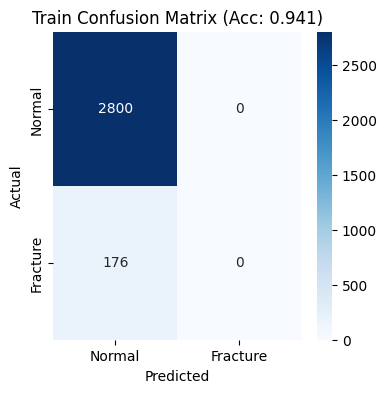

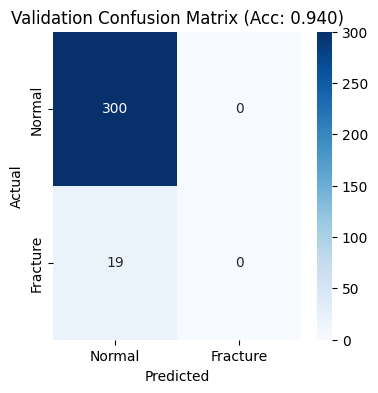

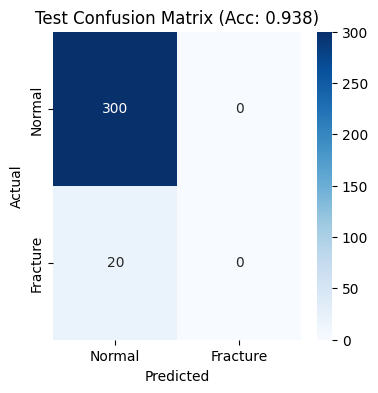

In [12]:

#  Evaluation with Confusion Matrices (Train / Val / Test)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def eval_gen(model, gen):
    """Evaluate model on a generator and compute metrics."""
    loss, acc = model.evaluate(gen, verbose=0)
    prob = model.predict(gen, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    y = gen.classes
    met = binary_metrics(y, pred, prob)
    rep = classification_report(y, pred, target_names=classes_ordered)
    boot = bootstrap_accuracy(y, pred, 1000 if not FAST_MODE else 200)
    return {"loss":loss,"acc":acc,"metrics":met,"report":rep,"boot_acc":boot, "y":y, "pred":pred}


train_eval = eval_gen(m, train_flow)
val_eval   = eval_gen(m, val_flow)
test_eval  = eval_gen(m, test_flow)

# Print reports
print("== Train ==")
print(train_eval["report"])
print("== Val ==")
print(val_eval["report"])
print("== Test ==")
print(test_eval["report"])
print("Bootstrap Acc (test):", test_eval["boot_acc"])


splits = {
    "Train": train_eval,
    "Validation": val_eval,
    "Test": test_eval
}

for name, result in splits.items():
    y_true = result["y"]
    y_pred = result["pred"]
    cm = confusion_matrix(y_true, y_pred)
    acc = result["acc"]
    
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"],
                yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix (Acc: {acc:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 12. Training Progress Visualization — Accuracy & Loss Curves

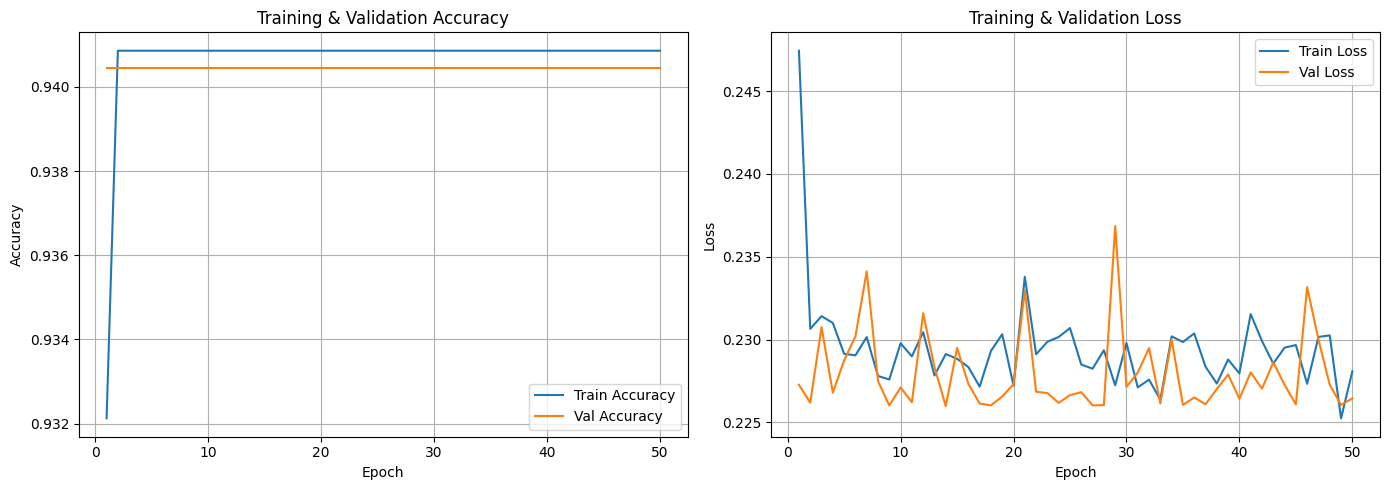

In [14]:
import matplotlib.pyplot as plt

def plot_training_curves(history_list):
    acc, val_acc, loss, val_loss = [], [], [], []

    for h in history_list:
        acc.extend(h.history.get("accuracy", []))
        val_acc.extend(h.history.get("val_accuracy", []))
        loss.extend(h.history.get("loss", []))
        val_loss.extend(h.history.get("val_loss", []))

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.grid(True)
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ---- detect what you actually have and plot ----
histories = []

if "hist1" in globals():
    histories.append(hist1)
if "hist2" in globals():
    histories.append(hist2)
if not histories and "hist" in globals():
    histories.append(hist)

if histories:
    plot_training_curves(histories)
else:
    print("No history object found (hist / hist1 / hist2). Train the model first.")


classes_ordered: ['fracture', 'normal']
186/186 ━━━━━━━━━━━━━━━━━━━━ 38s 202ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step

===== Train =====
Accuracy: 0.9409
Kappa: 0.0
AUC: 0.4519

Classification Report:
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97      2800
      normal       0.00      0.00      0.00       176

    accuracy                           0.94      2976
   macro avg       0.47      0.50      0.48      2976
weighted avg       0.89      0.94      0.91      2976



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


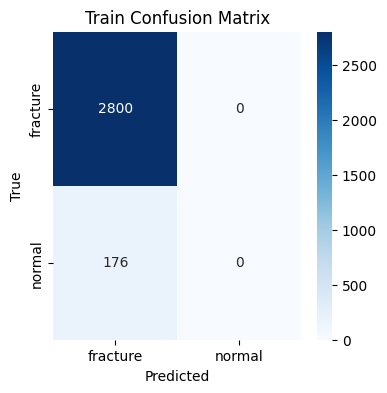

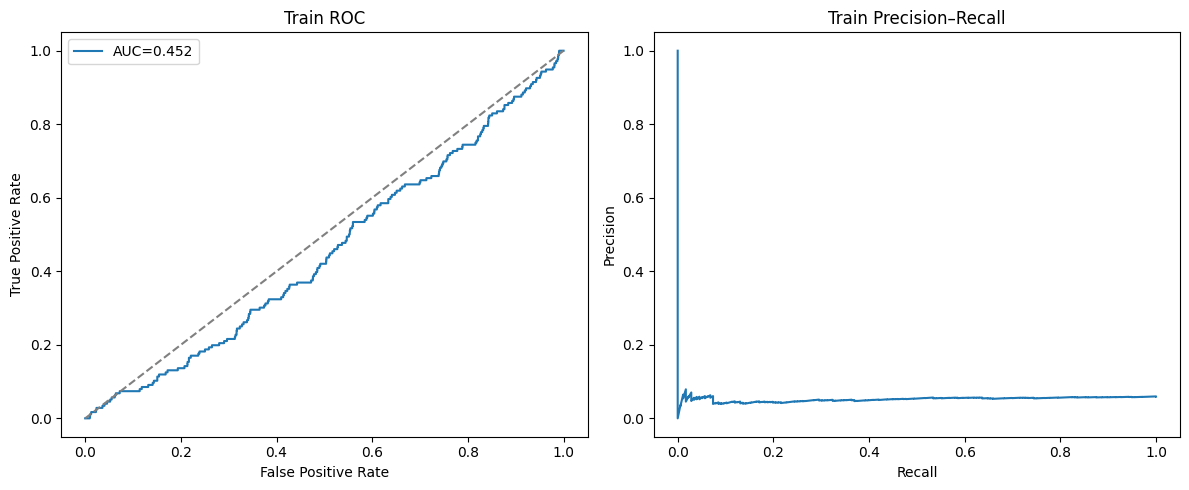


===== Validation =====
Accuracy: 0.9404
Kappa: 0.0
AUC: 0.6165

Classification Report:
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        19

    accuracy                           0.94       319
   macro avg       0.47      0.50      0.48       319
weighted avg       0.88      0.94      0.91       319



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


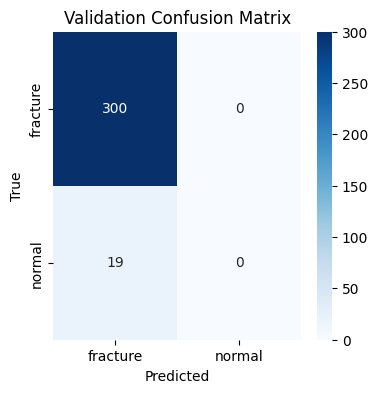

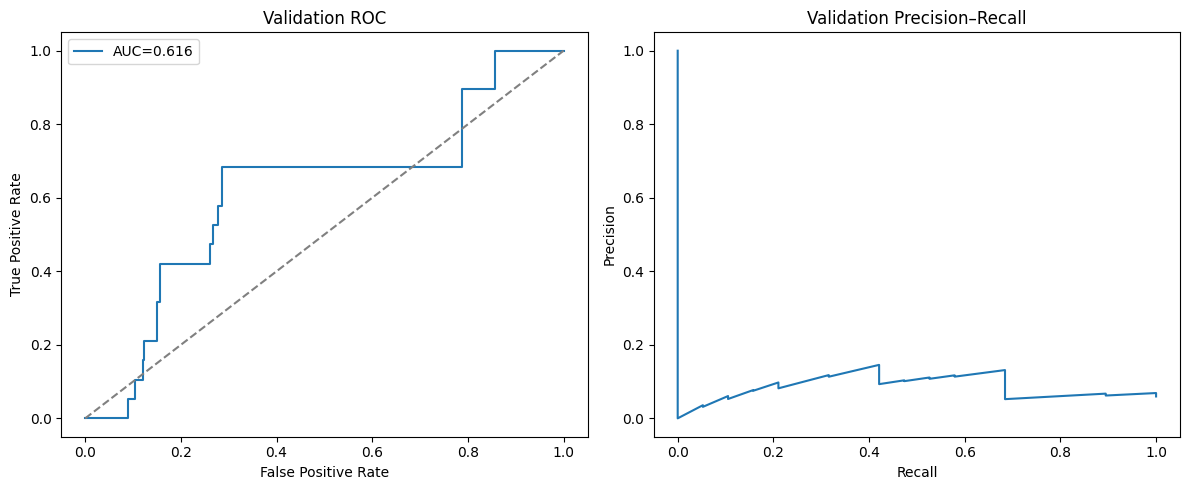


===== Test =====
Accuracy: 0.9375
Kappa: 0.0
AUC: 0.7377

Classification Report:
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


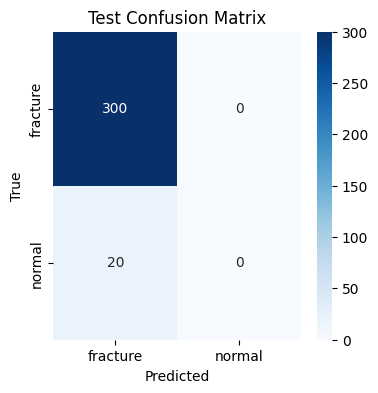

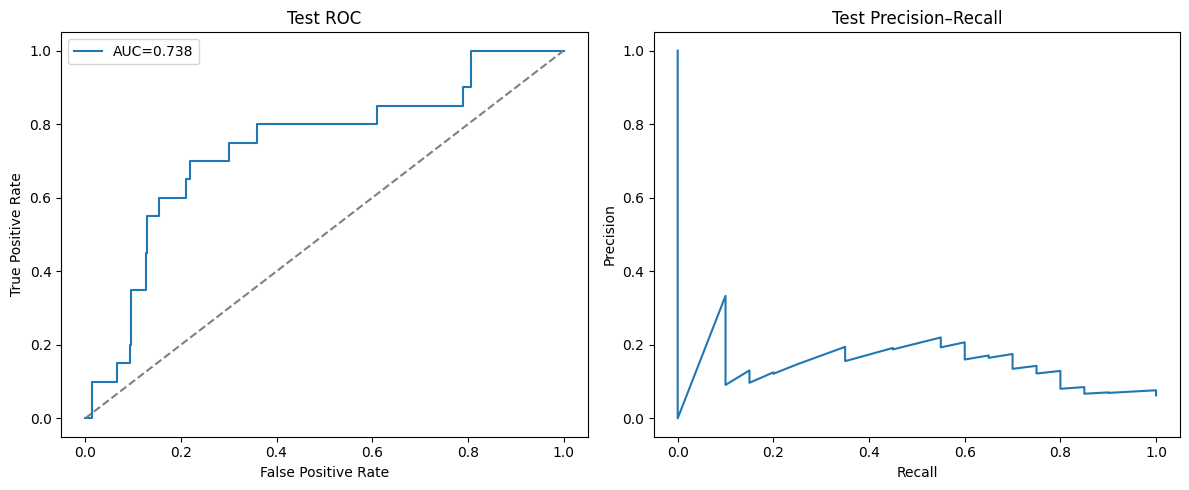


===== Summary Table =====


,Split,Accuracy,Kappa,AUC
0,Train,0.940860,0.0,0.451889
1,Validation,0.940439,0.0,0.616491
2,Test,0.937500,0.0,0.737667


In [16]:
# ============================================
#  METRICS & EVALUATION (Train / Val / Test)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    cohen_kappa_score, accuracy_score
)

# Use your trained model "m"
MODEL = m

# Class names from train_flow
idx_to_class = {v: k for k, v in train_flow.class_indices.items()}
classes_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]
print("classes_ordered:", classes_ordered)

def get_probs_and_labels(flow, model):
    """Predict probabilities, convert to labels, and return true labels."""
    probs = model.predict(flow, verbose=1).ravel()
    preds = (probs >= 0.5).astype(int)
    true  = flow.classes
    return true, preds, probs

# ---- Get predictions for each split ----
y_train_true, y_train_pred, y_train_prob = get_probs_and_labels(train_flow, MODEL)
y_val_true,   y_val_pred,   y_val_prob   = get_probs_and_labels(val_flow,   MODEL)
y_test_true,  y_test_pred,  y_test_prob  = get_probs_and_labels(test_flow,  MODEL)

def eval_split(name, y_true, y_pred, y_prob):
    acc   = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    try:
        auc   = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan

    print(f"\n===== {name} =====")
    print("Accuracy:", round(acc, 4))
    print("Kappa:", round(kappa, 4))
    print("AUC:", round(auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes_ordered))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes_ordered,
        yticklabels=classes_ordered
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC + PR curves
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        prec, rec, _ = precision_recall_curve(y_true, y_prob)

        plt.figure(figsize=(12,5))
        # ROC
        plt.subplot(1,2,1)
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],"--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} ROC")
        plt.legend()

        # Precision–Recall
        plt.subplot(1,2,2)
        plt.plot(rec, prec)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{name} Precision–Recall")
        plt.tight_layout()
        plt.show()
    except ValueError:
        print("ROC/PR could not be computed for this split (likely only one class present).")

    return acc, kappa, auc

# ---- Evaluate all splits ----
train_acc, train_kappa, train_auc = eval_split("Train",       y_train_true, y_train_pred, y_train_prob)
val_acc,   val_kappa,   val_auc   = eval_split("Validation",  y_val_true,   y_val_pred,   y_val_prob)
test_acc,  test_kappa,  test_auc  = eval_split("Test",        y_test_true,  y_test_pred,  y_test_prob)

# ---- Summary table ----
summary_df = pd.DataFrame({
    "Split":    ["Train", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc,    test_acc],
    "Kappa":    [train_kappa, val_kappa, test_kappa],
    "AUC":      [train_auc,  val_auc,   test_auc]
})

print("\n===== Summary Table =====")
display(summary_df)


## 13 CNN Backbone Training & Evaluation

###  Purpose
To identify which CNN backbone performs best for the given dataset by comparing accuracy, F1-score, precision, recall, and specificity.

### CNN Architectures Used
- **ResNet50** — Deep residual network with skip connections  
- **VGG16** — Simple sequential convolutional architecture  
- **InceptionV3** — Multi-scale feature extractor  
- **Xception** — Depthwise separable convolutions for efficiency  
- **DenseNet121** — Feature reuse via dense connections  
- **MobileNetV2** — Lightweight network for mobile applications  
- **EfficientNetB0** — Scaled architecture balancing depth, width, and resolution  
- **NASNetMobile** — Auto-searched network optimized for performance  



Using GPU for training: /physical_device:GPU:0
 Starting CNN training & evaluation for all backbones...

==================== ResNet50 ====================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training ResNet50 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8023 - loss: 0.4434
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/ResNet50_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 61s 259ms/step - accuracy: 0.8028 - loss: 0.4426 - val_accuracy: 0.9404 - val_loss: 0.2248 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9518 - loss: 0.1998
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9517 - loss: 0.1999 - val_accuracy: 0.9404 - val_loss: 0.2244 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9332 - loss: 0.2541
Epoch 3: val_accuracy did not imp

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



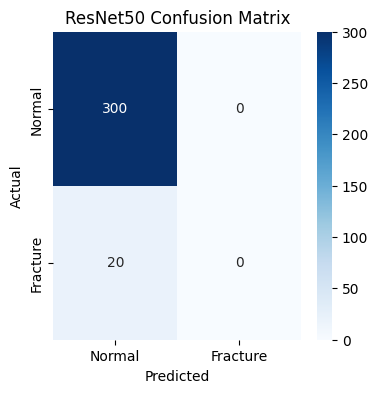

==================== VGG16 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training VGG16 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9232 - loss: 0.3034
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/VGG16_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 54s 254ms/step - accuracy: 0.9233 - loss: 0.3031 - val_accuracy: 0.9404 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9462 - loss: 0.2073
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 227ms/step - accuracy: 0.9462 - loss: 0.2074 - val_accuracy: 0.9404 - val_loss: 0.2197 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9407 - loss: 0.2159
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 227ms/step - accuracy: 0.9407 - loss: 0.2159 - val_accuracy: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


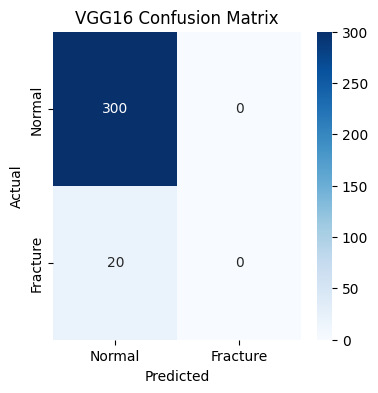

==================== InceptionV3 ====================
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training InceptionV3 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9240 - loss: 0.2725
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 70s 285ms/step - accuracy: 0.9241 - loss: 0.2724 - val_accuracy: 0.9404 - val_loss: 0.2162 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9349 - loss: 0.2063
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9349 - loss: 0.2063 - val_accuracy: 0.9404 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9359 - loss: 0.1860
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9359 - loss: 0.1860 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


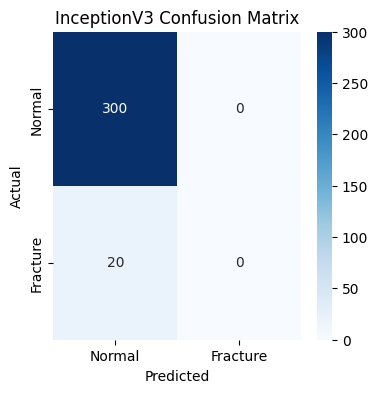

==================== Xception ====================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Xception for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9114 - loss: 0.2813
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/Xception_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 57s 254ms/step - accuracy: 0.9115 - loss: 0.2810 - val_accuracy: 0.9404 - val_loss: 0.2186 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9389 - loss: 0.1862
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 224ms/step - accuracy: 0.9389 - loss: 0.1861 - val_accuracy: 0.9404 - val_loss: 0.1969 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9467 - loss: 0.1671
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9467 - loss: 0.1671 - val_acc

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


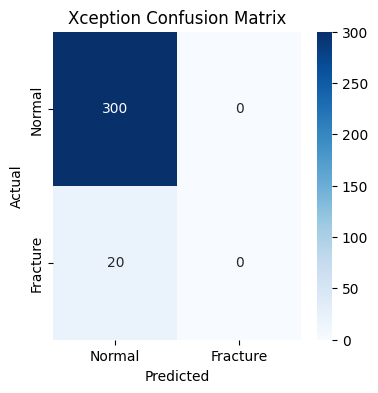

==================== DenseNet121 ====================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training DenseNet121 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8035 - loss: 0.4973
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/DenseNet121_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 92s 338ms/step - accuracy: 0.8041 - loss: 0.4963 - val_accuracy: 0.9404 - val_loss: 0.2153 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9410 - loss: 0.2223
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9410 - loss: 0.2223 - val_accuracy: 0.9404 - val_loss: 0.1911 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9404 - loss: 0.2032
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9404 - loss: 0.2032 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


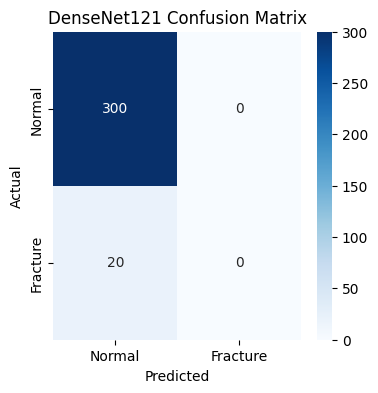

==================== MobileNetV2 ====================


/tmp/ipykernel_38/127028954.py:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training MobileNetV2 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8582 - loss: 0.3807
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 56s 249ms/step - accuracy: 0.8586 - loss: 0.3801 - val_accuracy: 0.9404 - val_loss: 0.2200 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9381 - loss: 0.2076
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 216ms/step - accuracy: 0.9381 - loss: 0.2075 - val_accuracy: 0.9404 - val_loss: 0.1975 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9437 - loss: 0.1806
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9437 - loss: 0.1806 - val_accuracy: 0.9373 - val_loss: 0.2046 - learning_rat

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


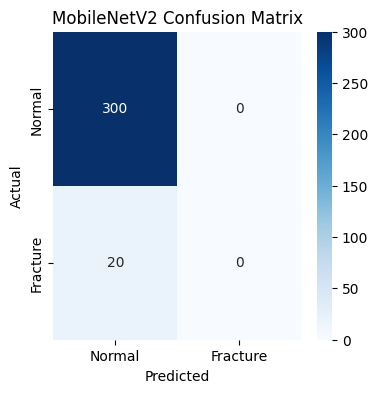

==================== EfficientNetB0 ====================

Training EfficientNetB0 for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8976 - loss: 0.2873
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 73s 271ms/step - accuracy: 0.8978 - loss: 0.2871 - val_accuracy: 0.9404 - val_loss: 0.2281 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9381 - loss: 0.2332
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9381 - loss: 0.2332 - val_accuracy: 0.9404 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9314 - loss: 0.2509
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 216ms/step - accuracy: 0.9314 - loss: 0.2508 - val_accuracy: 0.9404 - val_loss: 0.2268 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


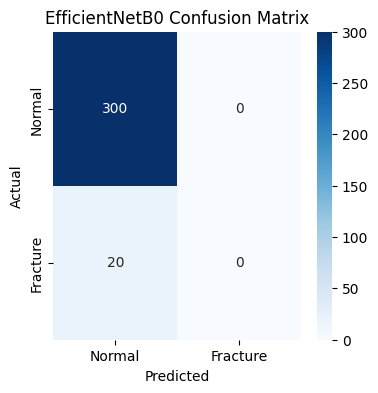

==================== NASNetMobile ====================
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training NASNetMobile for 15 epochs...
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9136 - loss: 0.2868
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 104s 348ms/step - accuracy: 0.9137 - loss: 0.2866 - val_accuracy: 0.9404 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9357 - loss: 0.2233
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9358 - loss: 0.2232 - val_accuracy: 0.9404 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9380 - loss: 0.1913
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9380 - loss: 0.1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


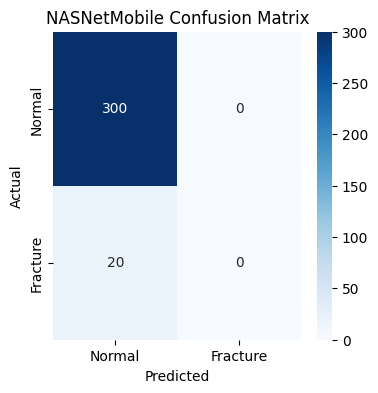


 CNN Leaderboard (Test Split):


,Model,Accuracy,F1-score,Precision,Recall,Specificity
0,ResNet50,0.9375,0.0,0.0,0.0,1.0
1,VGG16,0.9375,0.0,0.0,0.0,1.0
2,InceptionV3,0.9375,0.0,0.0,0.0,1.0
3,Xception,0.9375,0.0,0.0,0.0,1.0
4,DenseNet121,0.9375,0.0,0.0,0.0,1.0
5,MobileNetV2,0.9375,0.0,0.0,0.0,1.0
6,EfficientNetB0,0.9375,0.0,0.0,0.0,1.0
7,NASNetMobile,0.9375,0.0,0.0,0.0,1.0


In [17]:
# ==========================================================
# 8 CNN Backbones Training + Evaluation 
# ==========================================================
import os, gc
import pandas as pd
import tensorflow as tf
from IPython.display import display
from tensorflow.keras.applications import (
    ResNet50, VGG16, InceptionV3, Xception, DenseNet121,
    MobileNetV2, EfficientNetB0, NASNetMobile
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


RUN_CNN_MODELS = True
FULL_EPOCHS = 15
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)
WORK_DIR = "/kaggle/working/bone_fracture_work"
os.makedirs(WORK_DIR, exist_ok=True)


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    device_name = "/GPU:0"
    print("Using GPU for training:", gpus[0].name)
else:
    device_name = "/CPU:0"
    print(" No GPU found — using CPU.")


def build_keras_backbone(name):
    """Builds and compiles a CNN backbone model."""
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    if name == "ResNet50":
        base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "VGG16":
        base = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "InceptionV3":
        base = InceptionV3(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "Xception":
        base = Xception(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "DenseNet121":
        base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "MobileNetV2":
        base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "EfficientNetB0":
        base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "NASNetMobile":
        base = NASNetMobile(include_top=False, weights="imagenet", input_tensor=inputs)
    else:
        raise ValueError(f"Unknown backbone: {name}")

    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(inputs, out, name=f"{name}_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base


def fit_eval_model(model, name):
    """Trains a CNN and evaluates it using eval_gen."""
    E = FULL_EPOCHS
    ckpt_path = os.path.join(WORK_DIR, f"{name}_best.h5")

    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    print(f"\nTraining {name} for {E} epochs...")
    with tf.device(device_name):
        history = model.fit(
            train_flow,
            validation_data=val_flow,
            epochs=E,
            callbacks=cbs,
            verbose=1
        )

    print(f"\n Evaluating {name} on test data...")
    with tf.device(device_name):
        result = eval_gen(model, test_flow)

    # Handle dict-style eval_gen
    if isinstance(result, dict):
        res = result
        pred = res["pred"]
        y = res["y"]
        prob = None
    else:
        res, pred, prob, y = result

    print("Classification report:\n", res["report"])

    # Confusion Matrix
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"], yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return res, pred, prob, y, history


if RUN_CNN_MODELS:
    cnn_list = [
        "ResNet50", "VGG16", "InceptionV3", "Xception",
        "DenseNet121", "MobileNetV2", "EfficientNetB0", "NASNetMobile"
    ]
    results_cnn = []

    print(" Starting CNN training & evaluation for all backbones...\n")
    for arch in cnn_list:
        print(f"==================== {arch} ====================")
        tf.keras.backend.clear_session()
        gc.collect()

        with tf.device(device_name):
            m2, _ = build_keras_backbone(arch)
            res, pred, prob, y, hist = fit_eval_model(m2, arch)
            results_cnn.append({
                "name": arch,
                "test": res,
                "pred": pred,
                "prob": prob,
                "y": y
            })

        tf.keras.backend.clear_session()
        gc.collect()

    # Leaderboard
    df = pd.DataFrame(
        [[r["name"],
          float(r["test"]["acc"]),
          float(r["test"]["metrics"]["f1"]),
          float(r["test"]["metrics"]["precision"]),
          float(r["test"]["metrics"]["recall"]),
          float(r["test"]["metrics"]["specificity"])]
         for r in results_cnn],
        columns=["Model","Accuracy","F1-score","Precision","Recall","Specificity"]
    ).sort_values("Accuracy", ascending=False)

    print("\n CNN Leaderboard (Test Split):")
    display(df.reset_index(drop=True))
else:
    print("RUN_CNN_MODELS is False — manually force it True if you want to train CNNs.")


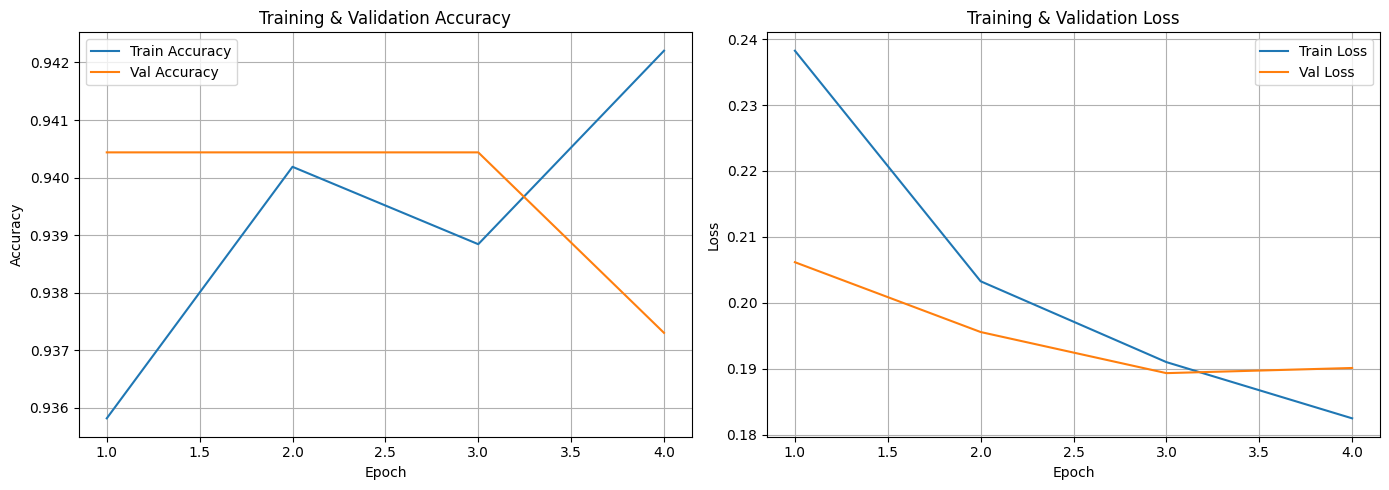

In [19]:
# ============================================
#   TRAINING CURVES (ACCURACY & LOSS)
# ============================================
import matplotlib.pyplot as plt

def plot_training_curves(history_list, label_list=None):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for h in history_list:
        acc.extend(h.history.get("accuracy", []))
        val_acc.extend(h.history.get("val_accuracy", []))
        loss.extend(h.history.get("loss", []))
        val_loss.extend(h.history.get("val_loss", []))

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # -------- Accuracy --------
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.grid(True)
    plt.legend()

    # -------- Loss --------
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================
#   DETECT WHICH HISTORY OBJECTS EXIST
# ============================================

histories = []

if "hist1" in globals():
    histories.append(hist1)
if "hist2" in globals():
    histories.append(hist2)

# If you only trained once and have `hist`
if not histories and "hist" in globals():
    histories.append(hist)

if histories:
    plot_training_curves(histories)
else:
    print("No history object found (hist / hist1 / hist2). Train the model first.")


## 14. CBAM Attention Module – EfficientNetB0 + CBAM Comparison

###  What is CBAM?
CBAM (Convolutional Block Attention Module) enhances CNN feature maps through two sequential attention mechanisms:
1. **Channel Attention** – Learns *which features* (filters) are important.  
2. **Spatial Attention** – Learns *where* to focus in the image.


### Outputs
- Confusion Matrices for **EfficientNetB0 (plain)** and **EfficientNetB0 + CBAM**  
- McNemar test statistics (`b`, `c`, and `p-value`)  
- Comparative accuracy summary for attention vs. non-attention models

CBAM setup → RUN_ATTENTION: True | device: /GPU:0 | classes_ordered: ['fracture', 'normal']

 Training EffB0_PLAIN for 15 epochs…
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9206 - loss: 0.2879
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 73s 279ms/step - accuracy: 0.9207 - loss: 0.2876 - val_accuracy: 0.9404 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9398 - loss: 0.2300
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 214ms/step - accuracy: 0.9398 - loss: 0.2300 - val_accuracy: 0.9404 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9310 - loss: 0.2572
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


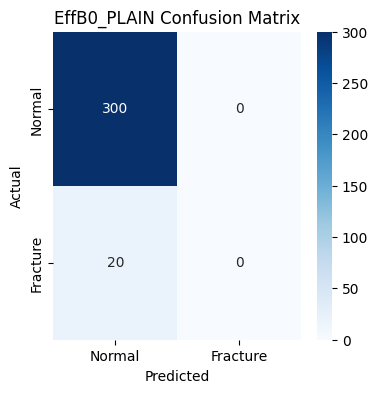


 Training EffB0_CBAM for 15 epochs…
Epoch 1/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9425 - loss: 0.2538
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 76s 285ms/step - accuracy: 0.9425 - loss: 0.2537 - val_accuracy: 0.9404 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 2/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9352 - loss: 0.2441
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.9352 - loss: 0.2440 - val_accuracy: 0.9404 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 3/15
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9444 - loss: 0.2175
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 214ms/step - accuracy: 0.9444 - loss: 0.2176 - val_accuracy: 0.9404 - val_lo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


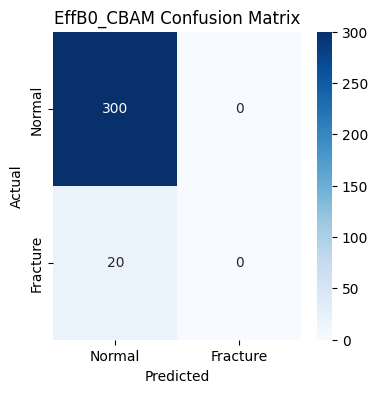


 McNemar: b=0, c=0, p-value=1.000000


In [21]:
# ==========================================================
# enable + train + evaluate + McNemar 
# ==========================================================
import os, gc, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K
from statsmodels.stats.contingency_tables import mcnemar


RUN_ATTENTION = True
if "IMG_SIZE" not in globals(): IMG_SIZE = (224, 224)
if "DROP" not in globals(): DROP = 0.5
if "L2" not in globals(): L2 = 1e-4
if "FULL_EPOCHS" not in globals(): FULL_EPOCHS = 15
if "FAST_MODE" not in globals(): FAST_MODE = False
if "WORK_DIR" not in globals(): WORK_DIR = "/kaggle/working/bone_fracture_work"
if "classes_ordered" not in globals(): classes_ordered = ["fracture","normal"]
os.makedirs(WORK_DIR, exist_ok=True)


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print("CBAM setup → RUN_ATTENTION:", RUN_ATTENTION, "| device:", device_name, "| classes_ordered:", classes_ordered)


def cbam_block(inp, r=8, name="cbam"):
    c = K.int_shape(inp)[-1]
    assert c is not None, "CBAM needs known channel dimension"
    c_mid = max(1, c // r)

    gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")(inp)
    gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(inp)
    shared_mlp = tf.keras.Sequential([
        layers.Dense(c_mid, activation="relu", name=f"{name}_fc1"),
        layers.Dense(c, activation=None, name=f"{name}_fc2"),
    ], name=f"{name}_mlp")
    ch = layers.Add(name=f"{name}_ch_add")([shared_mlp(gap), shared_mlp(gmp)])
    ch = layers.Activation("sigmoid", name=f"{name}_ch_sig")(ch)
    ch = layers.Reshape((1,1,c), name=f"{name}_ch_reshape")(ch)
    x = layers.Multiply(name=f"{name}_ch_mul")([inp, ch])

    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), name=f"{name}_sp_avg")(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True),  name=f"{name}_sp_max")(x)
    sp = layers.Concatenate(axis=-1, name=f"{name}_sp_concat")([avg_sp, max_sp])
    sp = layers.Conv2D(1, (7,7), padding="same", activation="sigmoid", name=f"{name}_sp_conv")(sp)
    out = layers.Multiply(name=f"{name}_sp_mul")([x, sp])
    return out


def build_plain_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_plain_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cbam_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_CBAM_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    feat = base.output
    x = cbam_block(feat, r=8, name="cbam")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m


def train_and_eval(model, tag, train_flow, val_flow, test_flow, epochs):
    ckpt = os.path.join(WORK_DIR, f"{tag}_best.h5")
    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]
    print(f"\n Training {tag} for {epochs} epochs…")
    with tf.device(device_name):
        model.fit(train_flow, validation_data=val_flow, epochs=epochs, callbacks=cbs, verbose=1)

        
        res = eval_gen(model, test_flow)
        if isinstance(res, dict):
            out = res
            y_true, y_pred = out["y"], out["pred"]
        else:
           
            out, y_pred, _, y_true = res

    print(f"\n== {tag} (test) ==")
    print(out["report"])

  
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Fracture"], yticklabels=["Normal","Fracture"])
    plt.title(f"{tag} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return out, y_pred, y_true


if RUN_ATTENTION:
   
    tf.keras.backend.clear_session(); gc.collect()
    m_plain = build_plain_efficientnet()
    res_plain, pred_plain, y_true = train_and_eval(
        m_plain, "EffB0_PLAIN", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 15)
    )

    tf.keras.backend.clear_session(); gc.collect()
    m_cbam = build_cbam_efficientnet()
    res_cbam, pred_cbam, y_true2 = train_and_eval(
        m_cbam, "EffB0_CBAM", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 15)
    )

  
    assert np.array_equal(y_true, y_true2), "Label mismatch between evaluations."

   
    agree_plain = (pred_plain == y_true)
    agree_cbam  = (pred_cbam  == y_true)
    b = int(np.sum((agree_plain == True)  & (agree_cbam == False)))  # plain correct, cbam wrong
    c = int(np.sum((agree_plain == False) & (agree_cbam == True)))   # cbam correct, plain wrong
    mc = mcnemar([[0, b], [c, 0]], exact=True)
    print(f"\n McNemar: b={b}, c={c}, p-value={mc.pvalue:.6f}")
else:
    print("RUN_ATTENTION is False; set it True to run CBAM.")


## 15. Ensemble Evaluation – Combining Multiple CNN Models

###  Outputs
- **Optimal Threshold:** Computed for best F1-score performance.  
- **Confusion Matrix:** Shows how well the ensemble distinguishes fractures from normal cases.  
- **Classification Report:** Displays precision, recall, and F1 metrics.  
- **Probability Histogram:** Visualizes prediction confidence per class.


 Using device: /GPU:0
 Searching recursively for models in: /kaggle/working/bone_fracture_work

 Loaded model: /kaggle/working/bone_fracture_work/DenseNet121_best.h5
 Failed to load /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_1696>',)
  • kwargs={'mask': 'None'}
 Loaded model: /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/InceptionV3_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
 Loaded model: /kaggle/working/bone_fracture_work/Res

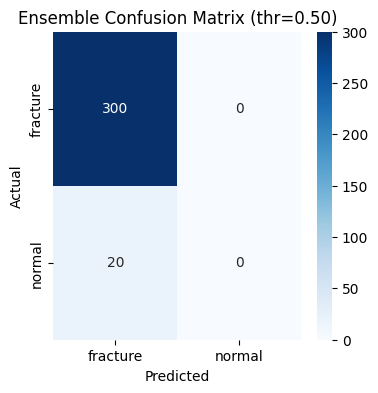

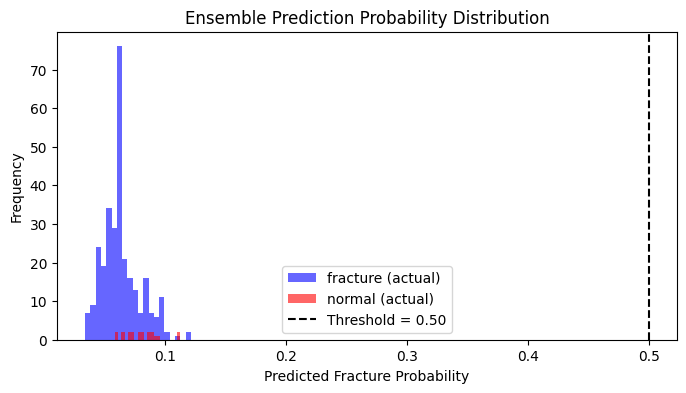

In [22]:

import os, numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


RUN_ENSEMBLE = True
RUN_CNN_MODELS = True


WORK_DIR = "/kaggle/working/bone_fracture_work"

if "test_flow" not in globals():
    raise RuntimeError("test_flow not defined — please run data loading cell first.")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")


def ensemble_predict(models_list, gen):
    """Average soft predictions (probabilities) from multiple Keras models."""
    preds_all = []
    for i, m in enumerate(models_list, 1):
        print(f"Running model {i}/{len(models_list)}: {m.name}")
        with tf.device(device_name):
            p = m.predict(gen, verbose=0).ravel()
        preds_all.append(p)

    preds_all = np.stack(preds_all, axis=0)
    mean_pred = np.mean(preds_all, axis=0)
    return mean_pred


if RUN_ENSEMBLE and RUN_CNN_MODELS:
    top_models = []
    print(f" Searching recursively for models in: {WORK_DIR}\n")

    
    for root, _, files in os.walk(WORK_DIR):
        for f in sorted(files):
            if f.endswith("_best.h5"):
                path = os.path.join(root, f)
                try:
                    with tf.device(device_name):
                        model = tf.keras.models.load_model(path)
                    top_models.append(model)
                    print(f" Loaded model: {path}")
                except Exception as e:
                    print(f" Failed to load {path}: {e}")

    if len(top_models) == 0:
        print(" No saved models found, using current model `m` if available.")
        if "m" in globals():
            top_models = [m]
        else:
            raise RuntimeError(" No models available for ensemble!")

    print(f"\nTotal models used for ensemble: {len(top_models)}")

  
    with tf.device(device_name):
        P = ensemble_predict(top_models, test_flow)

    y_true = np.array(test_flow.classes)
    labels = list(test_flow.class_indices.keys())

   
    best_thr, best_f1 = 0.5, 0
    for t in np.linspace(0.3, 0.7, 21):
        f1 = f1_score(y_true, (P >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    print(f"\n🔹 Optimal threshold for best F1: {best_thr:.2f}")

    yh = (P >= best_thr).astype(int)

    
    print("\n Ensemble Classification Report:")
    print(classification_report(y_true, yh, target_names=labels, digits=4, zero_division=0))

    
    cm = confusion_matrix(y_true, yh)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Ensemble Confusion Matrix (thr={best_thr:.2f})")
    plt.show()

   
    plt.figure(figsize=(8, 4))
    plt.hist(P[y_true == 0], bins=20, alpha=0.6, label=f"{labels[0]} (actual)", color='blue')
    plt.hist(P[y_true == 1], bins=20, alpha=0.6, label=f"{labels[1]} (actual)", color='red')
    plt.axvline(best_thr, color='black', linestyle="--", label=f"Threshold = {best_thr:.2f}")
    plt.title("Ensemble Prediction Probability Distribution")
    plt.xlabel("Predicted Fracture Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

else:
    print(" RUN_ENSEMBLE or RUN_CNN_MODELS is False — set both True to run ensemble evaluation.")


## 16. Grad-CAM 

### Outputs
   For each random image:
   -  Original X-ray  
   -  Grad-CAM Heatmap (model attention)  
   -  Overlay with predicted **fracture probability**

classes_ordered: ['fracture', 'normal']
Using preferred Grad-CAM layer: top_conv
Grad-CAM will use layer: top_conv
True: fracture, Pred: fracture, Prob: 0.053


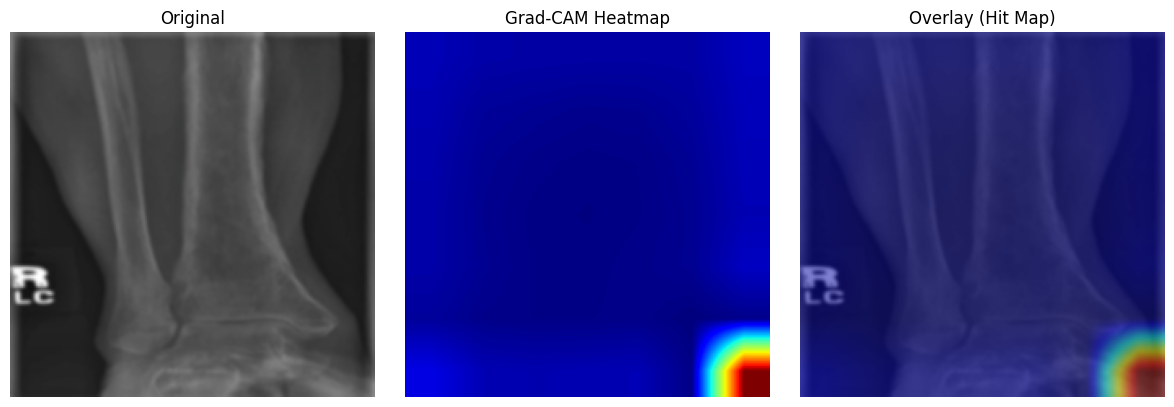

True: fracture, Pred: fracture, Prob: 0.053


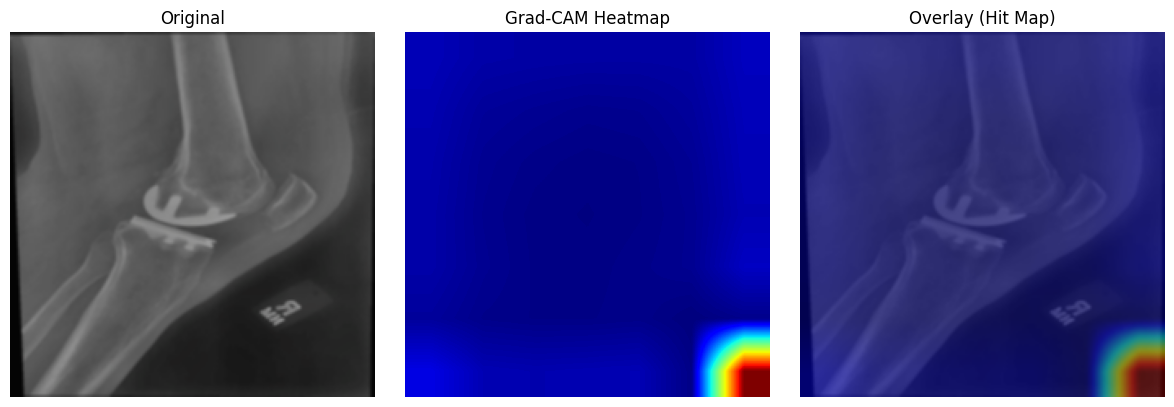

True: fracture, Pred: fracture, Prob: 0.053


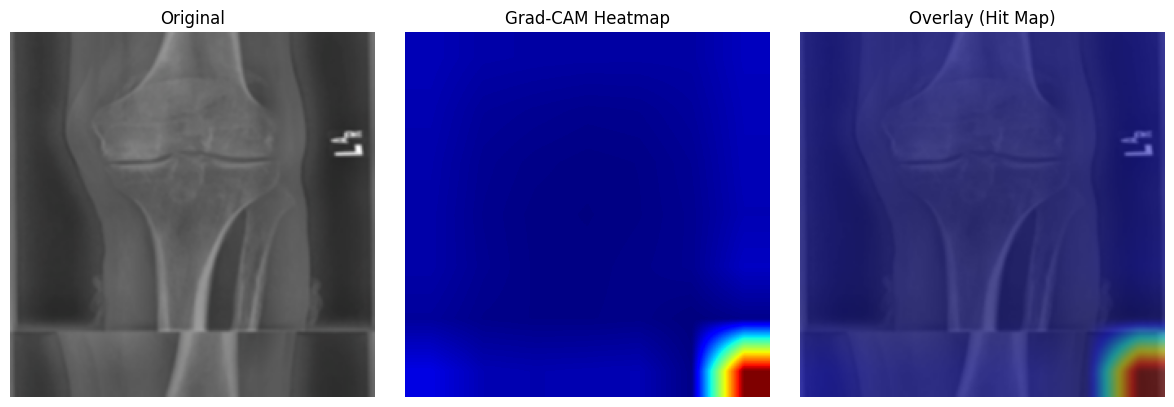

True: fracture, Pred: fracture, Prob: 0.053


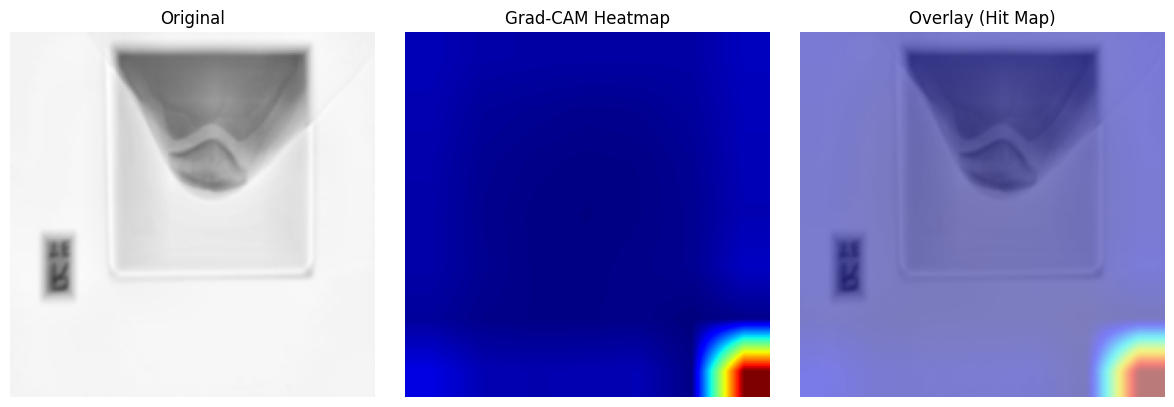

In [28]:
# ============================================
#          GRAD-CAM (FULL CELL)
#   Works with your model: m (binary)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers

# -------- 1. Use your trained model --------
MODEL = m

# If you already built classes_ordered before, you can reuse it.
# Otherwise we rebuild it from train_flow:
idx_to_class = {v: k for k, v in train_flow.class_indices.items()}
classes_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]
print("classes_ordered:", classes_ordered)

# -------- 2. Pick the best conv layer for Grad-CAM --------
def find_best_conv_layer(model):
    """
    Try to pick a reasonably deep conv layer with some spatial resolution.
    Works for EfficientNet, Xception, etc.
    """
    # First: if you know some good names, try them:
    preferred_names = [
        "top_conv",                 # EfficientNet
        "block7a_project_bn",       # EfficientNet
        "block6a_expand_activation",
        "block5_conv3",             # VGG style
        "block5_sepconv3",          # Xception-style
    ]
    for lname in preferred_names:
        try:
            layer = model.get_layer(lname)
            if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
                print("Using preferred Grad-CAM layer:", lname)
                return layer
        except:
            continue

    # Fallback: last conv-like layer with spatial dim >= 7x7
    for layer in reversed(model.layers):
        if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
            try:
                out_shape = layer.output_shape
                if len(out_shape) == 4:
                    h, w = out_shape[1], out_shape[2]
                    if (h is None or h >= 7) and (w is None or w >= 7):
                        print("Using auto-selected Grad-CAM layer:", layer.name, "shape:", out_shape)
                        return layer
            except:
                continue

    # Final fallback: last conv layer of the model
    for layer in reversed(model.layers):
        if isinstance(layer, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
            print("Using last conv layer as fallback:", layer.name)
            return layer

    raise RuntimeError("No suitable Conv2D-like layer found for Grad-CAM.")

last_conv_layer = find_best_conv_layer(MODEL)
GRADCAM_LAYER_NAME = last_conv_layer.name

# Model that outputs (feature_maps, predictions)
gradcam_model = models.Model(
    inputs=MODEL.input,
    outputs=[MODEL.get_layer(GRADCAM_LAYER_NAME).output, MODEL.output]
)
print("Grad-CAM will use layer:", GRADCAM_LAYER_NAME)

# -------- 3. Grad-CAM computation --------
def make_gradcam(img_array, class_index=0):
    """
    img_array: single image (H, W, 3), scaled exactly like during training
    class_index: for binary we usually ignore and just use the sigmoid output
    """
    img_tensor = tf.convert_to_tensor(img_array[None, ...])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(img_tensor, training=False)

        # Binary sigmoid: predictions shape (1,1)
        if predictions.shape[-1] == 1:
            loss = predictions[:, 0]
        else:
            loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)  # (1, h, w, c)

    # ReLU on gradients, then channel-wise mean
    grads = tf.nn.relu(grads)
    grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (c,)

    conv_outputs = conv_outputs[0]  # (h, w, c)
    heatmap = tf.reduce_sum(conv_outputs * grads, axis=-1)  # (h, w)

    # Normalize to [0,1] and sharpen
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap ** 2.0   # makes hot regions stronger

    return heatmap.numpy()

# -------- 4. Overlay function (Original + Heatmap + Hit map) --------
def show_gradcam_on_image(raw_img, heatmap, alpha=0.5):
    """
    raw_img: (H, W, 3) image, uint8 or float in [0,255]
    heatmap: (H, W) in [0,1]
    """
    import cv2

    # Ensure uint8 original
    if raw_img.dtype != np.uint8:
        img_disp = np.clip(raw_img, 0, 255).astype("uint8")
    else:
        img_disp = raw_img.copy()

    h, w = img_disp.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))

    heatmap_color = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_color = cv2.GaussianBlur(heatmap_color, (7, 7), 0)

    overlay = cv2.addWeighted(heatmap_color, alpha, img_disp, 1 - alpha, 0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img_disp)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay (Hit Map)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# -------- 5. Run Grad-CAM on a few images from test/val --------
import random

# Prefer test_flow; if not present, fall back to val_flow
batch_source = None
if "test_flow" in globals():
    batch_source = test_flow
else:
    batch_source = val_flow

x_batch, y_batch = next(iter(batch_source))
num_samples = min(4, x_batch.shape[0])
indices = random.sample(range(x_batch.shape[0]), num_samples)

for idx in indices:
    img = x_batch[idx]           # already resized & scaled (e.g., [0,1])
    true_label = int(y_batch[idx])

    prob = MODEL.predict(img[None, ...], verbose=0)[0, 0]
    pred_label = int(prob >= 0.5)

    heatmap = make_gradcam(img)
    print(f"True: {classes_ordered[true_label]}, Pred: {classes_ordered[pred_label]}, Prob: {prob:.3f}")
    # If your generator scales images to [0,1], multiply by 255
    show_gradcam_on_image(img * 255.0, heatmap, alpha=0.5)



## 17. Locate dataset automatically, build Mixt set, visualize ensemble


 Detected training folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Dataset
 Mixt test set created with 20 images at /kaggle/working/mixt_flat
 Using device: /GPU:0
 Loaded: DenseNet121_best.h5
Failed to load EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_1676>',)
  • kwargs={'mask': 'None'}
 Loaded: EffB0_PLAIN_best.h5
 Loaded: EfficientNetB0_best.h5
 Loaded: InceptionV3_best.h5
 Loaded: MobileNetV2_best.h5
 Loaded: NASNetMobile_best.h5
 Loaded: ResNet50_best.h5
 Loaded: VGG16_best.h5
 Loaded: Xception_best.h5


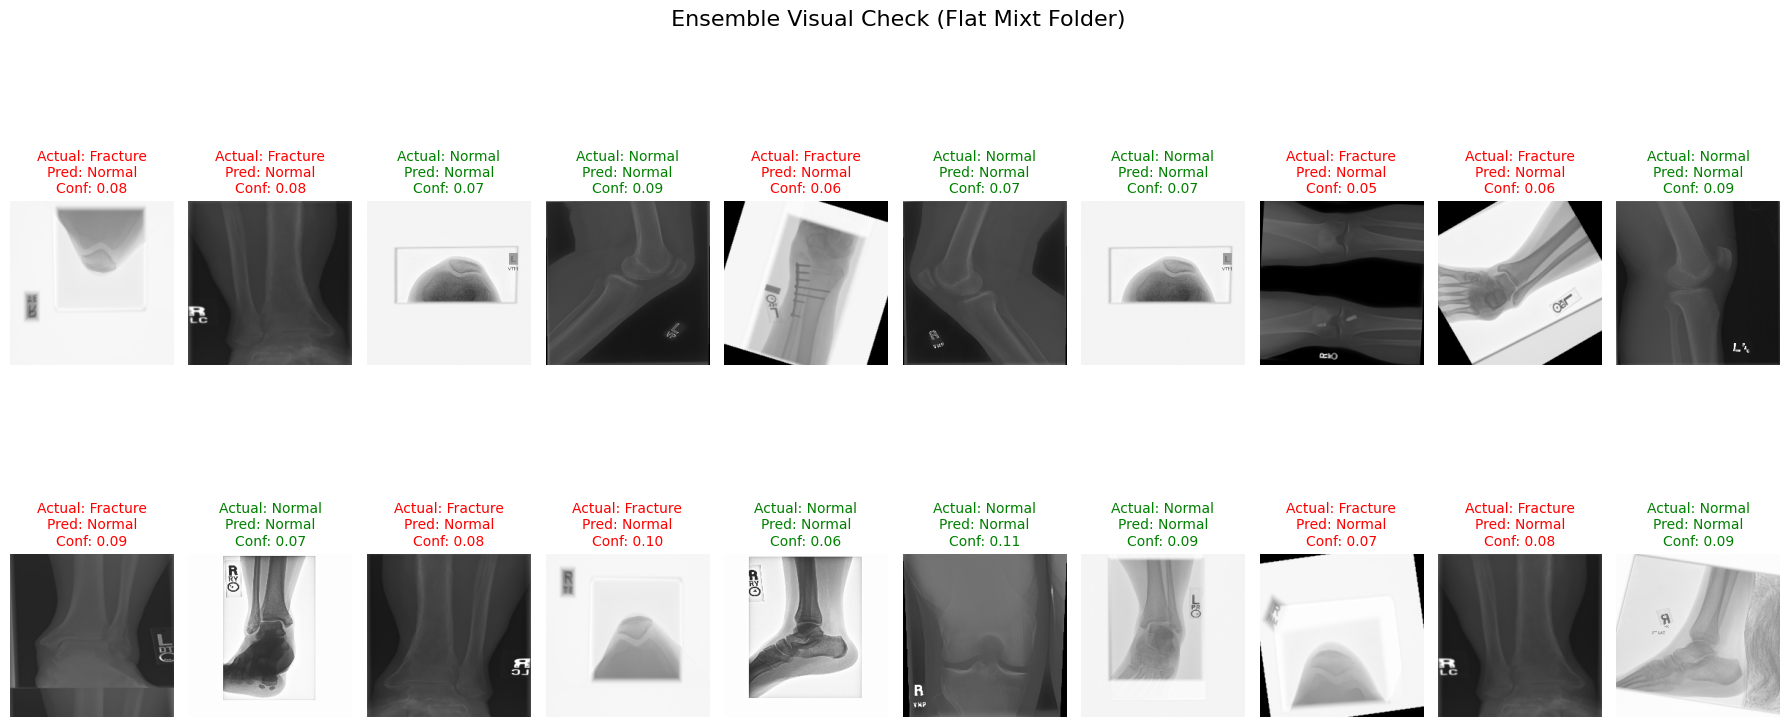

In [29]:

import os, random, shutil, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 
root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/",
]

SOURCE_TRAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_TRAIN = subdir
            break
    if SOURCE_TRAIN:
        break

if not SOURCE_TRAIN:
    raise FileNotFoundError(" Could not find dataset folders containing 'fracture' and 'normal'!")

print(f" Detected training folder: {SOURCE_TRAIN}")


MIXT_DIR = "/kaggle/working/mixt_flat"
WORK_DIR = "/kaggle/working/bone_fracture_work"
IMG_SIZE = (224, 224)
NUM_SAMPLES_PER_CLASS = 10  


if os.path.exists(MIXT_DIR):
    shutil.rmtree(MIXT_DIR)
os.makedirs(MIXT_DIR, exist_ok=True)

def copy_random_images(class_name, n=10):
    src_class_path = os.path.join(SOURCE_TRAIN, class_name)
    if not os.path.exists(src_class_path):
        raise FileNotFoundError(f" Folder not found: {src_class_path}")
    images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if len(images) == 0:
        raise ValueError(f" No images found in {src_class_path}")
    selected = random.sample(images, min(n, len(images)))
    for img in selected:
        shutil.copy2(os.path.join(src_class_path, img), os.path.join(MIXT_DIR, f"{class_name}_{img}"))

copy_random_images("fracture", NUM_SAMPLES_PER_CLASS)
copy_random_images("normal", NUM_SAMPLES_PER_CLASS)
print(f" Mixt test set created with {len(os.listdir(MIXT_DIR))} images at {MIXT_DIR}")


device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f" Using device: {device_name}")

models_list = []
for f in sorted(os.listdir(WORK_DIR)):
    if f.endswith("_best.h5"):
        model_path = os.path.join(WORK_DIR, f)
        try:
            with tf.device(device_name):
                model = tf.keras.models.load_model(model_path)
            models_list.append(model)
            print(f" Loaded: {f}")
        except Exception as e:
            print(f"Failed to load {f}: {e}")

if len(models_list) == 0:
    raise RuntimeError(" No trained models found in bone_fracture_work!")


def ensemble_predict_image(img_path):
    """Predicts average probability of 'fracture' using ensemble of models."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    arr = np.expand_dims(img.astype("float32") / 255.0, axis=0)

    preds = []
    for m in models_list:
        with tf.device(device_name):
            p = m.predict(arr, verbose=0)[0][0]
        preds.append(p)
    mean_prob = np.mean(preds)
    return mean_prob, img


images = [os.path.join(MIXT_DIR, f) for f in os.listdir(MIXT_DIR)
          if f.lower().endswith(('jpg', 'jpeg', 'png'))]
random.shuffle(images)

plt.figure(figsize=(18, 9))
for i, img_path in enumerate(images[:NUM_SAMPLES_PER_CLASS * 2]):
    prob, img = ensemble_predict_image(img_path)
    pred = "Fracture" if prob >= 0.5 else "Normal"
    actual = "Fracture" if "fracture" in img_path.lower() else "Normal"
    color = "green" if pred == actual else "red"

    plt.subplot(2, NUM_SAMPLES_PER_CLASS, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual}\nPred: {pred}\nConf: {prob:.2f}", color=color, fontsize=10)

plt.suptitle(" Ensemble Visual Check (Flat Mixt Folder)", fontsize=16)
plt.tight_layout()
plt.show()



## 18. 5-Fold Cross-Validation 


In [33]:
# ========= 5-Fold Cross Validation for EfficientNetB0 =========
from sklearn.model_selection import StratifiedKFold

def run_kfold_efficientnet(k=5, epochs=15):
    filepaths = []
    labels = []
    label_map = {c:i for i,c in enumerate(classes)}

    for c in classes:
        for p in all_paths[c]:
            filepaths.append(p)
            labels.append(label_map[c])

    filepaths = np.array(filepaths)
    labels = np.array(labels)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(filepaths, labels), 1):
        print(f"\n===== Fold {fold}/{k} =====")

        tr_files, tr_labels = filepaths[tr_idx], labels[tr_idx]
        va_files, va_labels = filepaths[val_idx], labels[val_idx]

        # generators for this fold
        fold_train_gen = ImageDataGenerator(
            rotation_range=25,
            width_shift_range=0.15,
            height_shift_range=0.15,
            zoom_range=0.20,
            shear_range=0.15,
            horizontal_flip=True,
            fill_mode="nearest",
            preprocessing_function=preprocessing_function
        )
        fold_val_gen = ImageDataGenerator(
            preprocessing_function=preprocessing_function
        )

        def make_flow(fp, lab, gen, shuffle):
            df = pd.DataFrame({"filename": fp, "class": lab})
            df["class"] = df["class"].map({0: classes[0], 1: classes[1]})
            return gen.flow_from_dataframe(
                df,
                x_col="filename",
                y_col="class",
                target_size=IMG_SIZE,
                class_mode="binary",
                batch_size=BATCH_SIZE,
                shuffle=shuffle
            )

        train_fold_flow = make_flow(tr_files, tr_labels, fold_train_gen, shuffle=True)
        val_fold_flow   = make_flow(va_files, va_labels, fold_val_gen, shuffle=False)

        tf.keras.backend.clear_session()
        fold_model, fold_base = build_efficientnet()

        es = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1)
        rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1)

        hist = fold_model.fit(
            train_fold_flow,
            epochs=epochs,
            validation_data=val_fold_flow,
            callbacks=[es, rlr],
            verbose=1
        )

        # eval on this fold
        y_true_f, y_pred_f, y_prob_f = get_probs_and_labels(val_fold_flow, fold_model)
        acc_f = accuracy_score(y_true_f, y_pred_f)
        kappa_f = cohen_kappa_score(y_true_f, y_pred_f)

        print(f"Fold {fold} accuracy = {acc_f:.4f}, kappa = {kappa_f:.4f}")
        fold_results.append({"fold": fold, "accuracy": acc_f, "kappa": kappa_f})

        del fold_model, fold_base, hist
        gc.collect()

    cv_df = pd.DataFrame(fold_results)
    print("\n===== 5-Fold Summary =====")
    print(cv_df)
    print("Mean accuracy:", cv_df["accuracy"].mean(), "±", cv_df["accuracy"].std())
    print("Mean kappa:", cv_df["kappa"].mean(), "±", cv_df["kappa"].std())
    return cv_df

RUN_FIVE_FOLD = True
if RUN_FIVE_FOLD:
    cv_results_df = run_kfold_efficientnet(k=5, epochs=15)
else:
    print("RUN_FIVE_FOLD is False — skipping cross-validation.")



===== Fold 1/5 =====
Found 1701 validated image filenames belonging to 2 classes.
Found 426 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 462ms/step - accuracy: 0.9246 - loss: 0.3017 - val_accuracy: 0.9390 - val_loss: 0.2315 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9436 - loss: 0.2204 - val_accuracy: 0.9390 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9402 - loss: 0.2348 - val_accuracy: 0.9390 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9387 - loss: 0.2338 - val_accuracy: 0.9390 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.9450 - loss: 0.2218 - val_accuracy: 0.9390 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9449 - loss: 0.2156 - val_accuracy: 0.9390 - val_loss: 0.2303 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the be

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 466ms/step - accuracy: 0.9236 - loss: 0.2993 - val_accuracy: 0.9390 - val_loss: 0.2304 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 304ms/step - accuracy: 0.9388 - loss: 0.2328 - val_accuracy: 0.9390 - val_loss: 0.2365 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9419 - loss: 0.2247 - val_accuracy: 0.9390 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9345 - loss: 0.2426 - val_accuracy: 0.9390 - val_loss: 0.2303 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - accuracy: 0.9324 - loss: 0.2496 - val_accuracy: 0.9390 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 301ms/step - accuracy: 0.9338 - loss: 0.2480 - val_accuracy: 0.9390 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the be

...

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 463ms/step - accuracy: 0.9172 - loss: 0.2912 - val_accuracy: 0.9412 - val_loss: 0.2250 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9435 - loss: 0.2181 - val_accuracy: 0.9412 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9352 - loss: 0.2555 - val_accuracy: 0.9412 - val_loss: 0.2253 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - accuracy: 0.9407 - loss: 0.2304 - val_accuracy: 0.9412 - val_loss: 0.2247 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - accuracy: 0.9337 - loss: 0.2492 - val_accuracy: 0.9412 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9407 - loss: 0.2360 - val_accuracy: 0.9412 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of the be

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 464ms/step - accuracy: 0.8796 - loss: 0.3292 - val_accuracy: 0.9412 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - accuracy: 0.9508 - loss: 0.1985 - val_accuracy: 0.9412 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.9461 - loss: 0.2138 - val_accuracy: 0.9412 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9335 - loss: 0.2555
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9335 - loss: 0.2553 - val_accuracy: 0.9412 - val_loss: 0.2258 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9494 - loss: 0.2062 - val_accuracy: 0.9412 - val_loss: 0.2248 - learning_rate: 3.0000e-04
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 69s 453ms/step - accuracy: 0.9455 - loss: 0.2810 - val_accuracy: 0.9412 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.9462 - loss: 0.2162 - val_accuracy: 0.9412 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.9450 - loss: 0.2203 - val_accuracy: 0.9412 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9377 - loss: 0.2381
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.9377 - loss: 0.2380 - val_accuracy: 0.9412 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.9377 - loss: 0.2368 - val_accuracy: 0.9412 - val_loss: 0.2243 - learning_rate: 3.0000e-04
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 295ms/step - accuracy: 0